In [32]:
train_path="/content/train.csv"

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
df=pd.read_csv(train_path)
df.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524164 entries, 0 to 524163
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         524164 non-null  int64  
 1   RhythmScore                524164 non-null  float64
 2   AudioLoudness              524164 non-null  float64
 3   VocalContent               524164 non-null  float64
 4   AcousticQuality            524164 non-null  float64
 5   InstrumentalScore          524164 non-null  float64
 6   LivePerformanceLikelihood  524164 non-null  float64
 7   MoodScore                  524164 non-null  float64
 8   TrackDurationMs            524164 non-null  float64
 9   Energy                     524164 non-null  float64
 10  BeatsPerMinute             524164 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 44.0 MB


In [36]:
df=df.dropna()

In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,524164.0,262081.500000,151313.257586,0.000000,131040.750000,262081.500000,393122.250000,524163.000000
RhythmScore,524164.0,0.632843,0.156899,0.076900,0.515850,0.634686,0.739179,0.975000
AudioLoudness,524164.0,-8.379014,4.616221,-27.509725,-11.551933,-8.252499,-4.912298,-1.357000
VocalContent,524164.0,0.074443,0.049939,0.023500,0.023500,0.066425,0.107343,0.256401
AcousticQuality,524164.0,0.262913,0.223120,0.000005,0.069413,0.242502,0.396957,0.995000
InstrumentalScore,524164.0,0.117690,0.131845,0.000001,0.000001,0.074247,0.204065,0.869258
LivePerformanceLikelihood,524164.0,0.178398,0.118186,0.024300,0.077637,0.166327,0.268946,0.599924
MoodScore,524164.0,0.555843,0.225480,0.025600,0.403921,0.564817,0.716633,0.978000
TrackDurationMs,524164.0,241903.692949,59326.601501,63973.000000,207099.876625,243684.058150,281851.658500,464723.228100
Energy,524164.0,0.500923,0.289952,0.000067,0.254933,0.511800,0.746000,1.000000


## Data Visualization

In [64]:
df=df.drop(['id'],axis=1)
col=df.columns

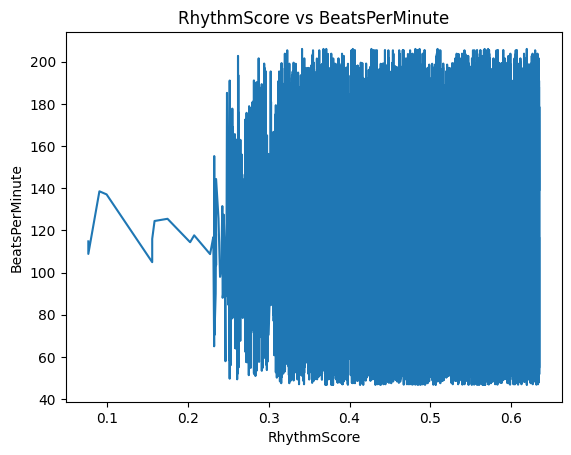

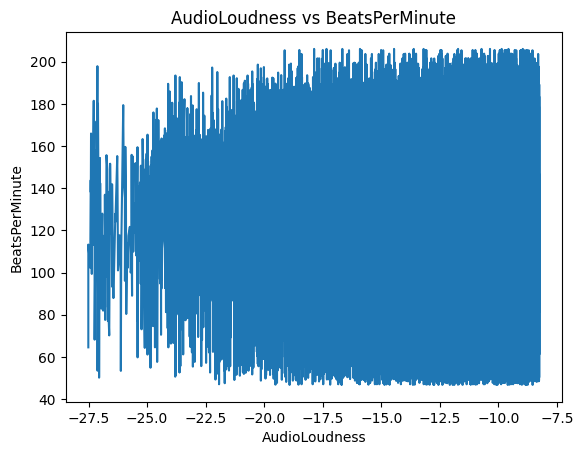

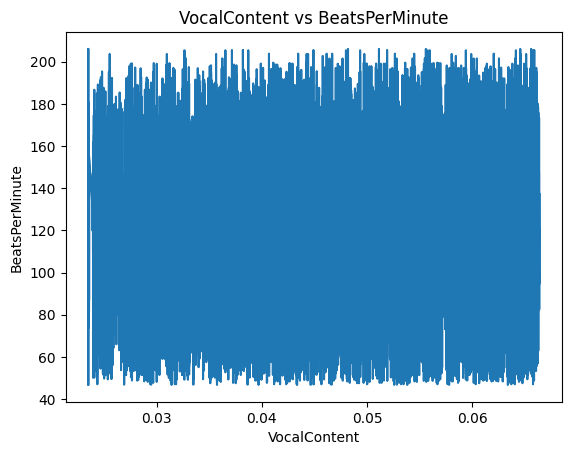

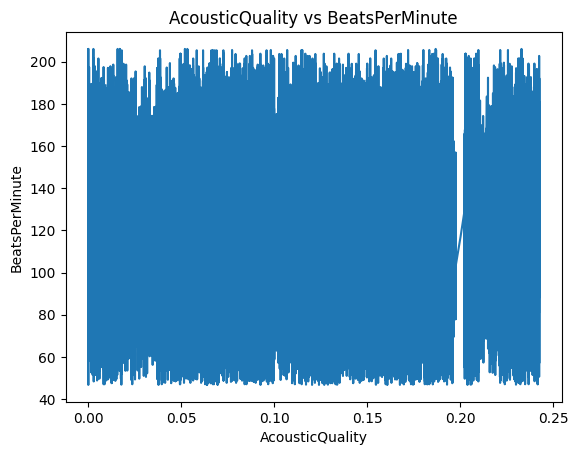

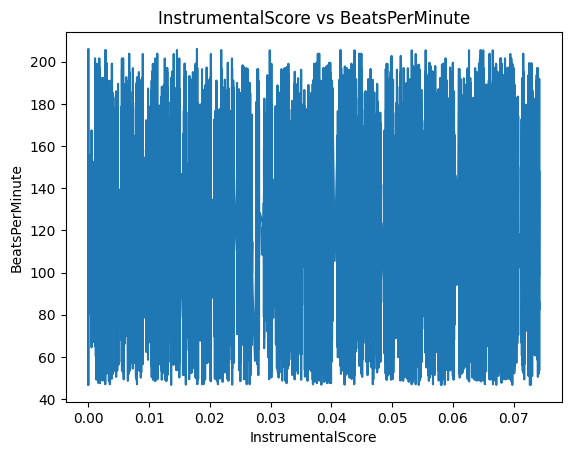

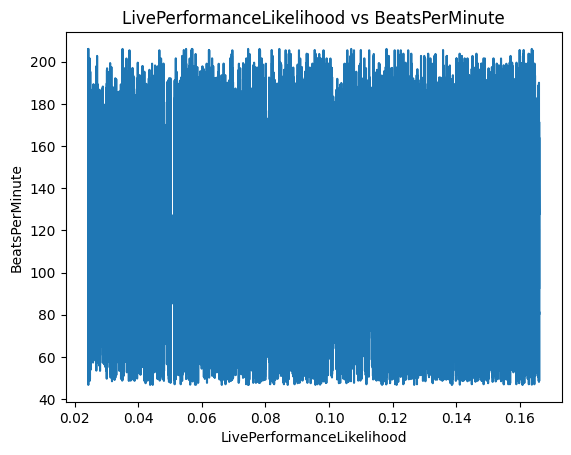

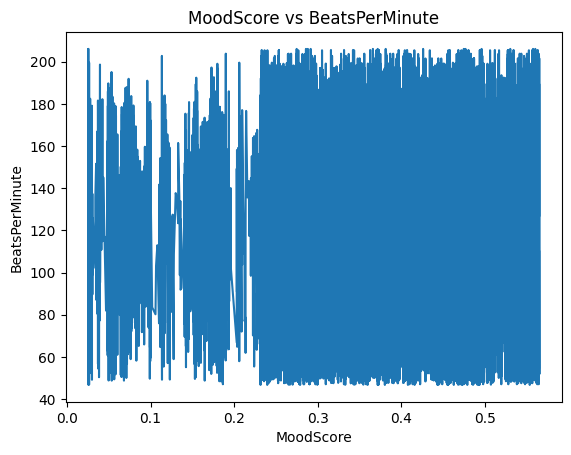

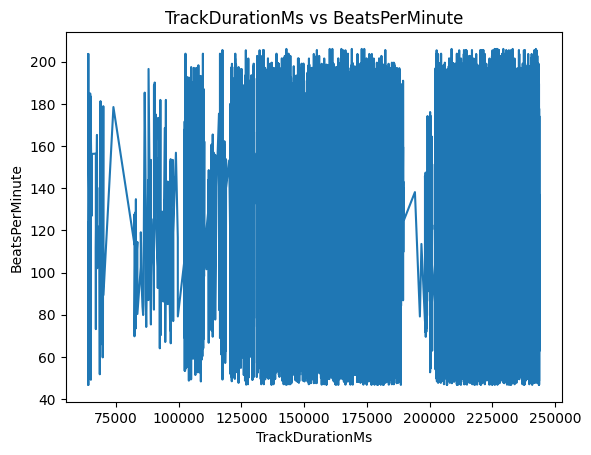

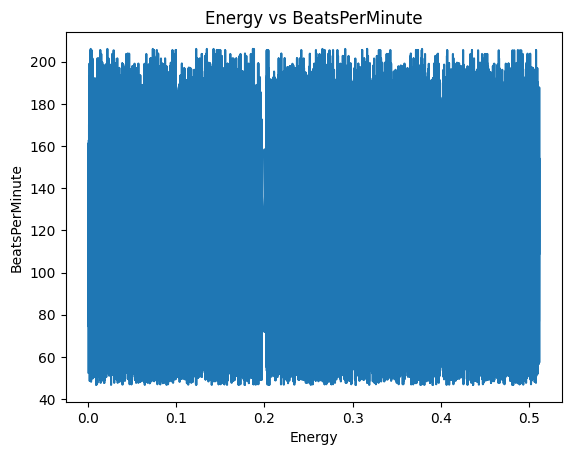

In [8]:
for i in col[:-1]:   # loop over all but last column
    # sort entire DataFrame by column i
    df_i = df.sort_values(by=i)
    plt.plot(df_i[i][:262000], df_i['BeatsPerMinute'][:262000])
    plt.xlabel(i)
    plt.ylabel("BeatsPerMinute")
    plt.title(f"{i} vs BeatsPerMinute")
    plt.show()

## Feature Engineering

In [65]:
def add_bpm_features(df: pd.DataFrame) -> pd.DataFrame:
    # Avoid division by zero
    df = df.copy()
    eps = 1e-6

    # Rhythm-related
    df['MoodRhythm'] = df['MoodScore'] * df['RhythmScore']
    df['RhythmPerSec'] = df['RhythmScore'] / ((df['TrackDurationMs'] / 1000) + eps)

    # Energy & Loudness
    df['EnergyPerSec'] = df['Energy'] / ((df['TrackDurationMs'] / 1000) + eps)
    df['LoudnessEnergy'] = df['AudioLoudness'] * df['Energy']
    df['DynamicRange'] = df['AudioLoudness'] * np.log1p(df['Energy'])

    # Instrumental vs Vocal
    df['VocalInstrumentalRatio'] = (df['VocalContent'] + 1) / (df['InstrumentalScore'] + 1)
    df['AcousticVocalBlend'] = (df['AcousticQuality'] + df['VocalContent']) / 2

    # Performance context
    df['PerfIndex'] = (0.6 * df['LivePerformanceLikelihood']) + (0.4 * df['Energy'])
    df['PartyScore'] = (0.5 * df['Energy']) + (0.3 * df['AudioLoudness']) + (0.2 * df['RhythmScore'])

    # Advanced combinations
    df['TempoVector'] = np.sqrt((df['RhythmScore']**2) + (df['InstrumentalScore']**2))
    df['MoodTempo'] = df['MoodScore'] * (df['Energy'] + df['RhythmScore'])

    return df

In [66]:
df=add_bpm_features(df)
df.head()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute,...,RhythmPerSec,EnergyPerSec,LoudnessEnergy,DynamicRange,VocalInstrumentalRatio,AcousticVocalBlend,PerfIndex,PartyScore,TempoVector,MoodTempo
0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020,...,0.002076,0.002842,-6.310151,-4.599530,1.023499,0.011753,0.361338,-1.757227,0.603610,0.586058
1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963,...,0.003887,0.000884,-2.365309,-2.208390,0.794063,0.258224,0.160473,-4.679689,0.728689,0.510946
2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989,...,0.002949,0.003580,-9.965667,-7.742313,0.764000,0.142207,0.267612,-4.370832,0.686073,0.482869
3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212,...,0.003256,0.002161,-0.661492,-0.538830,0.907949,0.027308,0.246806,-0.016474,0.751628,0.340607
4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511,...,0.002491,0.004428,-12.368798,-8.701605,1.023499,0.046093,0.577741,-3.336671,0.532968,0.707242


## Model training

In [41]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [67]:
X=df.drop(['BeatsPerMinute'],axis=1)
y=df['BeatsPerMinute']

In [68]:
sc=StandardScaler()
X=sc.fit_transform(X)

In [69]:
x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

## LightGBM

In [56]:
!pip install lightgbm

In [70]:
from lightgbm import LGBMRegressor
gbm=LGBMRegressor()
gbm.fit(
    x_train, y_train,
    eval_metric='rmse'
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.081488 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 393123, number of used features: 20
[LightGBM] [Info] Start training from score 119.032942


LGBMRegressor()

In [71]:
y_pred=gbm.predict(x_test)
print(mean_squared_error(y_test,y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


700.2914782206732


## Testing dataset

In [72]:
df_test=pd.read_csv("/content/test.csv")
df_test.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy
0,524164,0.410013,-16.794967,0.023500,0.232910,0.012689,0.271585,0.664321,302901.5498,0.424867
1,524165,0.463071,-1.357000,0.141818,0.057725,0.257942,0.097624,0.829552,221995.6643,0.846000
2,524166,0.686569,-3.368928,0.167851,0.287823,0.210915,0.325909,0.304978,357724.0127,0.134067
3,524167,0.885793,-5.598049,0.118488,0.000005,0.376906,0.134435,0.487740,271790.3989,0.316467
4,524168,0.637391,-7.068160,0.126099,0.539073,0.068950,0.024300,0.591248,277728.5383,0.481067


In [75]:
df_test=add_bpm_features(df_test)
id=df_test['id']
df_test.drop(['id'],axis=1,inplace=True)

In [76]:
y_pred_new=gbm.predict(df_test)

In [77]:
submission=pd.DataFrame({'id':id,'BeatsPerMinute':y_pred_new})
submission.to_csv('submission.csv',index=False)